# 06_特征选择方法-嵌入法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/BostonHousing.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天来和大家聊聊特征选择方法，嵌入法\~

特征选择方法中的「嵌入法」是一种在模型训练过程中自动选择最有用特征的方法。

简单来说，它就是在构建模型的同时，让模型自己判断哪些特征对最终预测结果最重要，哪些不重要，从而选择出最有价值的特征。

#### 更简单的一个解释：

在机器学习中，我们经常会有很多特征（比如数据的不同属性或变量），但是并不是所有特征都对模型的预测有帮助。有些特征可能是多余的，甚至是噪音，会影响模型的效果。为了提高模型的表现，我们需要“挑选”出最有用的特征。

嵌入法就是让模型在训练时自动挑选重要的特征。它不像过滤法（先挑特征再训练模型）或者包裹法（使用外部算法来评估特征的效果）那样是单独做的，它是在模型训练的过程中就一起做的。

#### 如何工作：

1. 训练模型时，嵌入法会通过学习数据中的特征与预测结果之间的关系，自动给每个特征分配一个重要性分数。
2. 不重要的特征会被“丢弃”，剩下重要的特征会被用于最终的模型训练。

举个例子，假设我们在做房价预测的模型，特征有房子的面积、楼层、周围的学校、交通方便程度等。通过嵌入法，模型会根据数据训练的过程，自己找出哪些特征（比如“面积”）对预测房价更重要，而哪些（比如“楼层”）则可能是多余的。

嵌入法的核心是通过模型训练过程来自动选择特征，不需要人为地干预或提前筛选特征。这种方法通常能找到最适合的特征组合，因此它是比较智能和高效的特征选择方法。

## 原理详解

### 一、数学原理

在特征选择中，嵌入法通过**模型的训练过程**来评估特征的重要性。

**嵌入法的核心思想是：训练一个模型，并在模型训练过程中，自动选择出对最终预测结果贡献最大的特征。**

通常，嵌入法在训练过程中利用某种**正则化技术**来抑制不重要的特征，从而减少模型复杂度，提高模型性能。

#### 正则化方法

在很多机器学习算法中，特别是线性回归、逻辑回归等，我们可以通过添加正则化项来减少不重要特征的影响。

常见的正则化方法有：

- **L1 正则化（Lasso 回归）**
- **L2 正则化（Ridge 回归）**

正则化的引入实际上是将**特征选择**与**模型训练**结合在一起，目标是找到一个“最简洁”的模型，即通过训练找出对目标最有用的特征，同时保持模型的简洁性。

### 二、数学推理

#### L1 正则化（Lasso 回归）

L1 正则化用于线性回归模型中，它的损失函数为：


$$
\mathcal{L}(\mathbf{w}) = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 + \lambda \sum_{j=1}^{p} |w_j|
$$


- $y_i$：真实值
- $\hat{y_i}$：预测值
- $\mathbf{w}$：模型的权重系数（即特征的权重）
- $\lambda$：正则化参数，控制模型的复杂度
- $w_j$：第 $j$ 个特征的权重

L1 正则化的关键是**绝对值**，它鼓励某些特征的权重 $w_j$ 为零，从而实现特征选择。具体来说，通过选择合适的 $\lambda$ 参数，L1 正则化会将某些特征的权重推向零，去除对模型无用的特征。

#### L2 正则化（Ridge 回归）

L2 正则化的损失函数为：


$$
\mathcal{L}(\mathbf{w}) = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 + \lambda \sum_{j=1}^{p} w_j^2
$$


- $w_j$：第 $j$ 个特征的权重

与 L1 正则化不同，L2 正则化通过**平方**来惩罚特征的权重，鼓励权重系数更接近零，但不会完全为零。

因此，L2 正则化的效果是“压缩”特征的重要性，而不像 L1 正则化那样完全去除不重要的特征。

### 三、算法流程

嵌入法的具体算法流程可以分为以下几步：

#### 模型选择

首先选择一个基础模型，这通常是一个带有正则化的模型。例如：

- 线性回归（用于回归问题）
- 逻辑回归（用于分类问题）
- 支持向量机（SVM）等

#### 特征权重初始化

在训练开始时，模型会根据所有输入特征（假设为 $X_1, X_2, ..., X_p$）初始化权重系数 $w_1, w_2, ..., w_p$。

#### 正则化项计算

计算模型的损失函数，其中包含正则化项。假设我们选择 L1 正则化，则损失函数为：


$$
\mathcal{L}(\mathbf{w}) = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 + \lambda \sum_{j=1}^{p} |w_j|
$$


其中，$\sum_{i=1}^{n} (y_i - \hat{y_i})^2$ 是模型的预测误差，$\lambda \sum_{j=1}^{p} |w_j|$ 是正则化项。

#### 梯度下降或优化方法

通过梯度下降法或其他优化方法（如坐标下降法），最小化损失函数。这个过程会更新权重 $w_j$，并且通过正则化项抑制那些不重要的特征。最终，某些特征的权重 $w_j$ 会趋近于零，从而实现特征选择。

#### 特征选择

经过模型训练后，重要特征的权重 $w_j$ 会较大，而不重要特征的权重 $w_j$ 会接近零或完全为零。可以根据权重的大小来选择特征。

#### 模型评估

最终，通过选出的重要特征，使用训练好的模型进行预测。并评估模型的性能（如准确率、均方误差等），确保选出的特征组合能够有效提高模型的预测能力。

### 四、公式推导

以下是通过Lasso回归（L1正则化）推导出如何利用正则化实现特征选择的详细过程：

1. **损失函数**：  
$\mathcal{L}(\mathbf{w}) = \sum_{i=1}^{n} (y_i - \hat{y_i})^2 + \lambda \sum_{j=1}^{p} |w_j|$  
其中，$\hat{y_i}$ 为模型的预测输出，$y_i$ 为实际标签，$\mathbf{w}$ 为模型的权重参数。
2. **梯度计算**：
3. 对于 L1 正则化，梯度计算会得到：  
$\frac{\partial \mathcal{L}(\mathbf{w})}{\partial w_j} = -2 \sum_{i=1}^{n} (y_i - \hat{y_i}) x_{ij} + \lambda \cdot \text{sign}(w_j)$  
其中：$x_{ij}$ 是第 $i$ 个样本的第 $j$ 个特征值。$\text{sign}(w_j)$ 表示权重 $w_j$ 的符号（取 $-1$、$0$ 或 $1$）。
4. **梯度下降更新**：
5. 根据梯度下降算法，通过计算梯度来更新每个特征的权重 $w_j$：  
$w_j \leftarrow w_j - \alpha \frac{\partial \mathcal{L}(\mathbf{w})}{\partial w_j}$  
其中，$\alpha$ 是学习率。
6. **特征选择**：
7. 当模型训练结束后，所有的特征的权重 $w_j$ 都会得到更新。如果某个特征的权重 $w_j$ 变为零或者接近零，说明这个特征对模型的贡献较小，可以认为它是一个不重要的特征，通常会被剔除。

## 完整案例

在本案例中，我们使用**Lasso回归**（L1正则化）来进行特征选择。Lasso回归是一种嵌入法，它通过引入L1正则化来惩罚模型中不重要的特征，将其系数推向零，从而达到特征选择的目的。

我们将使用一个**房价预测**数据集来演示如何应用Lasso回归进行特征选择，并进行结果的可视化和分析。

#### 实验步骤

1. 数据加载与预处理
2. 使用Lasso回归进行特征选择
3. 模型训练与评估
4. 可视化结果与分析
5. 算法优化

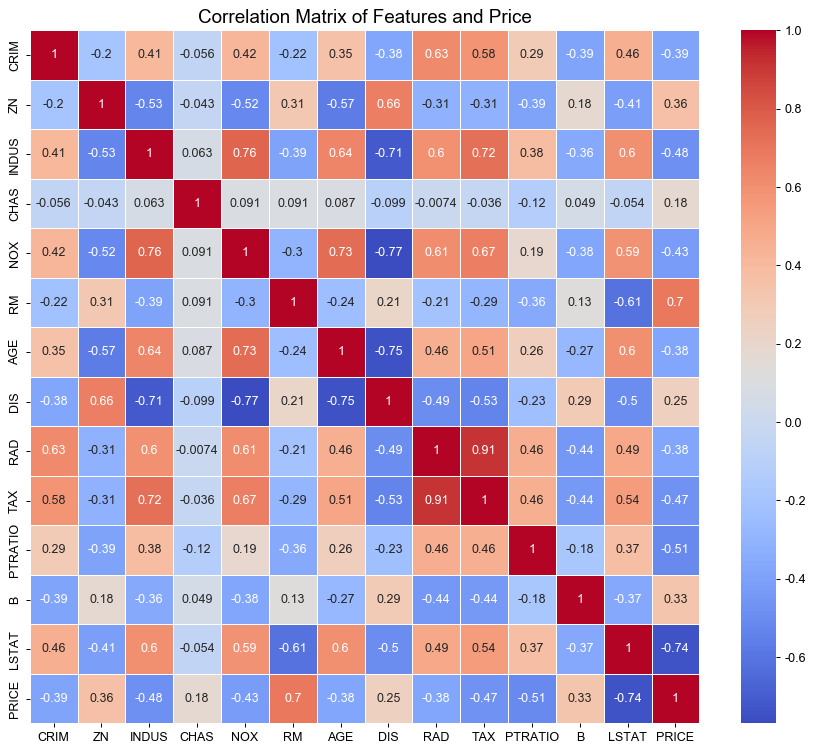

         Coefficient
CRIM       -0.700552
ZN          0.256615
INDUS      -0.000000
CHAS        0.688573
NOX        -1.557390
RM          3.243104
AGE        -0.000000
DIS        -2.261254
RAD         0.667039
TAX        -0.338474
PTRATIO    -1.845910
B           1.028481
LSTAT      -3.621010


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9874/692311984.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.index, y=coefficients['Coefficient'], palette='Set2')


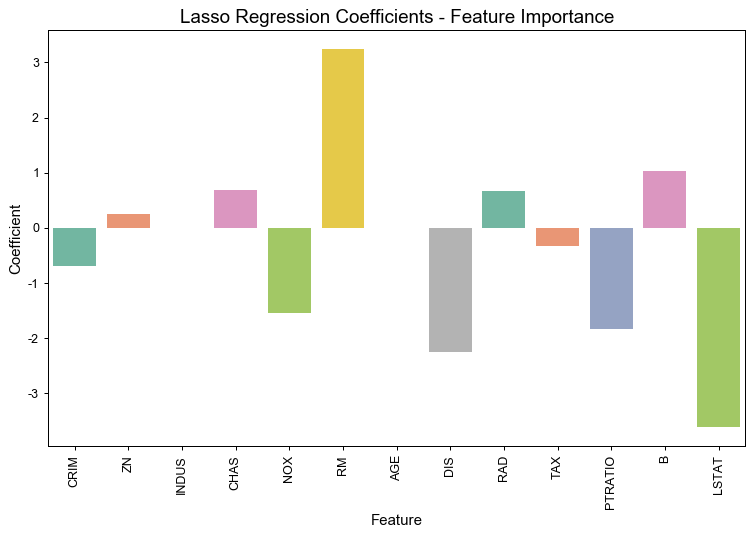

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectFromModel

# 1. 数据加载与预处理
# 读取波士顿房价数据集（可以换成其他合适的数据集）
from notebook_support import load_local_boston
boston = load_local_boston()
df = pd.DataFrame(boston.data, columns=boston.feature_names)
df['PRICE'] = boston.target  # 房价作为目标变量

# 查看前几行数据
df.head()

# 2. 数据可视化 - 各特征之间的相关性矩阵
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Features and Price", fontsize=15)
plt.show()

# 3. 数据分割 - 特征与目标变量
X = df.drop(columns=['PRICE'])
y = df['PRICE']

# 4. 特征缩放 - 由于Lasso回归对特征尺度敏感，进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. 数据分割为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. 使用Lasso回归进行特征选择
# 选择合适的alpha值，alpha越大，正则化作用越强
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# 查看各特征的系数
coefficients = pd.DataFrame(lasso.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

# 7. 可视化特征系数 - 重要特征和不重要特征的区别
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.index, y=coefficients['Coefficient'], palette='Set2')
plt.xticks(rotation=90)
plt.title("Lasso Regression Coefficients - Feature Importance", fontsize=15)
plt.ylabel('Coefficient', fontsize=12)
plt.xlabel('Feature', fontsize=12)
plt.show()

Mean Squared Error (MSE) of the model: 25.07057202781439


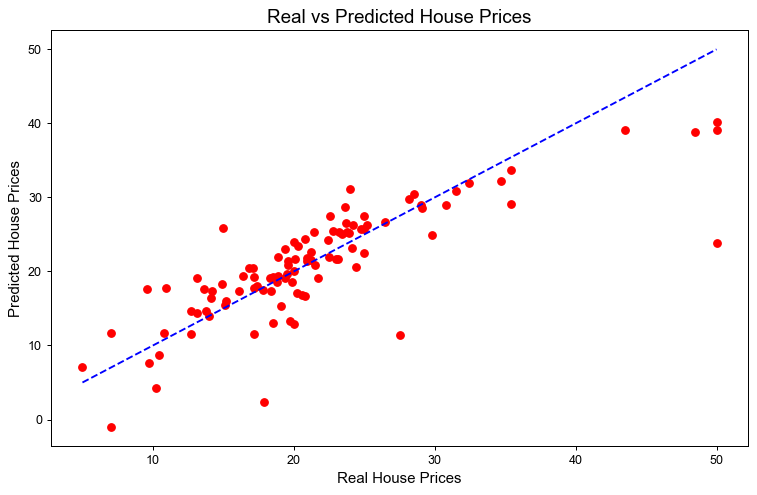

Best alpha value: 0.0001
Optimized Mean Squared Error (MSE): 24.291473735573266


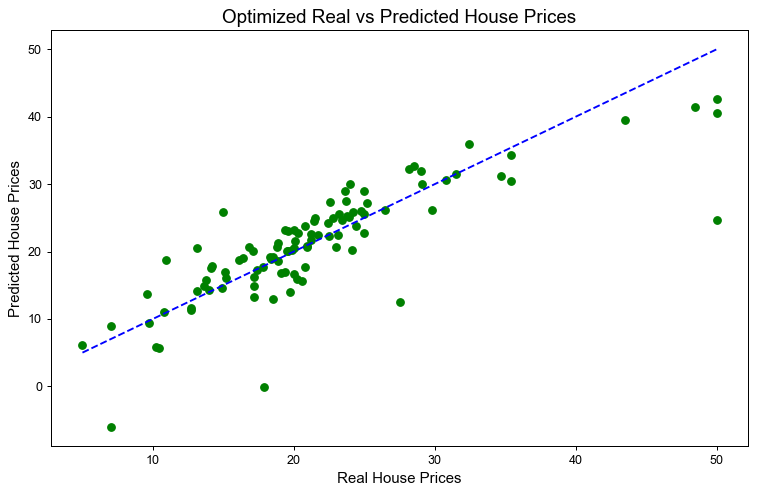

In [3]:
# 8. 使用SelectFromModel进行特征选择
model = SelectFromModel(lasso, threshold="mean", max_features=5)
model.fit(X_train, y_train)
X_train_selected = model.transform(X_train)
X_test_selected = model.transform(X_test)

# 9. 训练选择后的模型
lasso_selected = Lasso(alpha=0.1)
lasso_selected.fit(X_train_selected, y_train)

# 模型评估
y_pred = lasso_selected.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) of the model: {mse}")

# 可视化真实值与预测值的对比
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='red')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='blue')
plt.title("Real vs Predicted House Prices", fontsize=15)
plt.xlabel("Real House Prices", fontsize=12)
plt.ylabel("Predicted House Prices", fontsize=12)
plt.show()

# 进一步优化 - 通过交叉验证选择最优的alpha
from sklearn.model_selection import GridSearchCV

# 设置Lasso回归的参数范围
param_grid = {'alpha': np.logspace(-4, 0, 50)}
lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error', error_score='raise')
lasso_cv.fit(X_train, y_train)

# 查看最佳alpha值
print(f"Best alpha value: {lasso_cv.best_params_['alpha']}")

# 使用最佳alpha值训练模型
lasso_optimal = Lasso(alpha=lasso_cv.best_params_['alpha'])
lasso_optimal.fit(X_train, y_train)

# 评估优化后的模型
y_pred_optimal = lasso_optimal.predict(X_test)
mse_optimal = mean_squared_error(y_test, y_pred_optimal)
print(f"Optimized Mean Squared Error (MSE): {mse_optimal}")

# 可视化优化后的真实值与预测值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_optimal, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='blue')
plt.title("Optimized Real vs Predicted House Prices", fontsize=15)
plt.xlabel("Real House Prices", fontsize=12)
plt.ylabel("Predicted House Prices", fontsize=12)
plt.show()

#### 1. 数据加载与预处理

在这个步骤中，我们使用的是**波士顿房价数据集**，它是一个经典的回归数据集，其中包含13个特征（如犯罪率、房间数、房龄等）以及目标变量（房价）。我们将数据加载到Pandas DataFrame中，并查看数据的前几行。

#### 2. 数据可视化 - 相关性矩阵

为了了解特征之间的关系，我们绘制了相关性矩阵图。通过热力图，我们可以直观地看到各特征之间的相关性。例如，特征“房间数”（RM）与房价（PRICE）可能有较强的正相关。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

#### 3. 特征缩放

由于Lasso回归（L1正则化）对特征的尺度比较敏感，因此我们对特征进行了标准化。标准化是为了确保每个特征的均值为0，方差为1，从而避免特征尺度差异对模型训练的影响。

#### 4. 数据分割

将数据分为训练集和测试集，使用80%的数据进行训练，20%的数据进行测试。

#### 5. Lasso回归进行特征选择

我们使用Lasso回归来对特征进行选择。通过指定Lasso的超参数 $\alpha$，我们可以控制正则化的强度。较大的 $\alpha$ 会将更多特征的系数推向零，从而实现特征选择。

#### 6. 特征系数可视化

绘制了特征系数的条形图，展示了每个特征的系数大小。通过这种方式，我们可以看到哪些特征被Lasso回归模型认为更重要，哪些被推向零或接近零。

#### 7. 使用 SelectFromModel 进行特征选择

`SelectFromModel` 是一个常用的特征选择方法，基于模型的系数来选择特征。我们使用 `threshold="mean"` 选择了平均系数以上的重要特征。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

#### 8. 模型训练与评估

我们在选定特征上训练了一个新的Lasso回归模型，并用测试集进行预测。通过计算均方误差（MSE），我们评估了模型的性能。

#### 9. 结果可视化

为了直观展示模型预测效果，我们绘制了真实房价与预测房价的散点图。通过观察散点图，我们可以看到模型的预测效果。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

#### 优化 - 交叉验证选择最佳的alpha值

通过**交叉验证**（GridSearchCV），我们选择了最优的Lasso回归超参数 $\alpha$ 值。交叉验证可以帮助我们选择最适合的数据集的模型超参数，避免过拟合。

#### 优化后的结果评估与可视化

在使用最优的 $\alpha$ 值训练模型后，我们再次评估了模型性能，并绘制了优化后的真实值与预测值的对比图，进一步展示优化后的效果。

![原文参考图，当前结果见代码输出](attachments/img_015.png)

### 算法优化

在上面的代码中，我们通过交叉验证选择了最优的超参数 $\alpha$，这是Lasso回归模型的重要优化手段。通过这种方式，我们确保模型能够更好地拟合数据，并且在避免过拟合的同时进行特征选择。

除了交叉验证，还有其他方法可以优化模型性能，比如使用不同的特征选择方法、调整正则化参数的范围、甚至结合不同的模型进行集成学习等。

本案例整个的内容，展示了如何使用Lasso回归进行特征选择，并通过可视化手段对结果进行分析。在特征选择的过程中，我们通过引入L1正则化（Lasso）来自动选择重要特征，并且通过交叉验证优化了模型的超参数。最终，通过可视化工具和模型评估，我们能够更好地理解特征选择的效果和优化带来的提升。

## 模型分析

### 优缺点

**优点**：

1. **自动化特征选择**：嵌入法（如Lasso回归）通过在训练过程中自动选择重要特征，无需人工干预。这种方法能够在模型训练的同时，自动评估特征的重要性，从而减少了预处理过程中手动选择特征的复杂性。
2. **减少过拟合**：Lasso回归通过L1正则化对不重要特征的权重进行惩罚，能够将这些特征的系数推向零，实际上实现了特征的“去除”，减少了过拟合的风险。通过正则化，模型可以简化并专注于最关键的特征。
3. **适应性强**：嵌入法能够通过模型本身的学习过程来选择特征，不需要预先设定任何特征选择策略或依据特征之间的相关性。特别是在处理高维数据时，能够自适应地选择出最具代表性的特征。
4. **计算效率较高**：在与其他方法（如包裹法）相比时，嵌入法的计算效率通常较高。包裹法需要多次训练模型，而嵌入法则是在训练过程中通过正则化来实现特征选择，从而避免了重复的训练过程。

**缺点**：

1. **对数据标准化敏感**：Lasso回归（以及其他基于正则化的模型）对输入特征的尺度非常敏感，因此在使用该方法前必须对特征进行标准化。如果输入数据的特征尺度不一致，可能会导致模型性能较差。
2. **可能丧失一些信息**：虽然Lasso回归能够有效地进行特征选择，但它通过将特征系数压缩为零来“去除”特征，可能会忽略一些在复杂模型中可能有价值的特征。特别是当某些特征之间存在多重共线性时，Lasso可能过度简化模型，导致信息丢失。
3. **依赖于超参数的选择**：Lasso回归的正则化强度由超参数 $\alpha$ 控制。若超参数选择不当，可能导致模型表现不佳。对于不同的任务，需要通过交叉验证来选择最合适的超参数，这会增加一定的计算负担。
4. **适用于线性关系**：Lasso回归假设特征与目标变量之间存在线性关系。因此，如果数据中的特征与目标变量之间的关系是非线性的，Lasso回归可能无法捕捉到这种复杂关系，导致模型性能下降。

### 嵌入法与相似特征选择方法的对比

在机器学习中，常见的特征选择方法有三种：**过滤法**、**包裹法**和**嵌入法**。下面是这些方法的对比：

| 特征选择方法 | 特点 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|-|
| **过滤法** | 根据特征与目标变量之间的相关性或统计检验结果进行特征选择。 | 简单高效，易于理解。适合于特征维度较高时使用。 | 仅依赖于统计指标，忽略了特征与模型之间的关系。 | 当特征之间的相关性较强时，过滤法能够快速筛选出最重要的特征。 |
| **包裹法** | 使用某个模型评估特征子集的性能，逐步选择最优特征组合。 | 可以利用模型的实际预测能力来选择最优特征组合。 | 计算开销大，需要多次训练模型。 | 当模型需要高度定制且计算资源充足时，包裹法非常有效。 |
| **嵌入法** | 通过训练模型来自动选择特征，正则化过程可以去除不重要的特征。 | 自动选择特征，避免过拟合，计算效率较高。 | 对特征尺度敏感，可能忽略一些潜在重要特征。 | 当数据特征多且希望在训练过程中进行特征选择时，嵌入法是一个优选。 |

### 在什么情况下选择嵌入法？

1. **高维数据**：当数据集包含大量特征时，嵌入法通过正则化机制能够有效筛选出最相关的特征。相比于包裹法，嵌入法的计算成本较低，因此在高维数据的情况下，嵌入法会是更好的选择。
2. **模型中需要特征选择和正则化同时进行时**：当我们希望通过训练模型的同时实现特征选择和模型正则化时，嵌入法（如Lasso回归）是一种非常高效的方法。它不仅能够进行特征选择，还能够通过L1正则化避免过拟合。
3. **数据规模较大且特征间有相关性时**：在特征较多且存在相关性时，嵌入法通过正则化机制（如L1正则化）能够有效减少不必要的特征，避免特征冗余。相比于过滤法，嵌入法能够更精确地选择出对目标有较大贡献的特征。

### 何时可以考虑其他特征选择方法？

1. **特征之间关系复杂，非线性**：当特征与目标变量之间的关系是非线性的时，Lasso回归的表现可能不佳。在这种情况下，可以考虑使用包裹法或其他非线性模型（如决策树、随机森林等）来进行特征选择，因为这些模型可以更好地捕捉复杂的非线性关系。
2. **特征数目非常庞大，计算资源有限**：如果数据集的特征数量非常庞大，而计算资源又比较有限，包裹法可能不适用，因为它需要多次训练模型。此时，过滤法会是一个不错的选择，因为它只依赖于统计量来筛选特征，计算开销较小。
3. **模型需要特征选择与模型性能优化分开**：在某些情况下，我们可能更关注模型的性能优化，而不是特征选择的过程。例如，在处理一些复杂模型时，可能更愿意将特征选择与模型训练分开，选择包裹法来通过逐步选择特征和训练模型的方式来获得最优特征组合。

### 总结

**嵌入法**（如Lasso回归）作为一种特征选择方法，具有自动化高效、能够减少过拟合、计算成本较低等优点，因此在处理高维数据时特别有效。然而，它对特征的尺度比较敏感，并且假设数据之间的关系是线性的。如果数据具有复杂的非线性关系，或者计算资源较为紧张时，可以考虑其他特征选择方法（如包裹法或过滤法）。

**选择嵌入法的场景**通常是在特征较多、数据规模大，且我们希望同时进行特征选择和模型正则化时。而在需要捕捉非线性关系或处理大规模数据集时，其他方法可能更加合适。